# DWC26 – Exploratory Data Analysis (annotated)
**Goal:** understand the simulated reservoir ensemble *before* modelling – data quality, parameter coverage, how the 4 inputs drive the 3 output curves, and what the observed history can (and cannot) tell us.

**Data used:** only the engineered files in `data_after_engineering/`. Outcome statistics use **train + validation** cases; **test (86-100) is never touched** for outcomes.

| Parameter | Meaning (as named in the dataset) |
|---|---|
| `fault_trans` | fault transmissibility |
| `poro_mult` | porosity multiplier |
| `perm_mult` | permeability multiplier |
| `aquifer_pv` | aquifer pore volume |

**Headline findings:** (1) data is clean; (2) `poro_mult` controls ~99% of the variation in final cumulative volumes; (3) `perm_mult` and `aquifer_pv` only appear after the porosity trend is removed; (4) the history pins down porosity but leaves the other parameters largely free; (5) the history is mid-way through a rate decline / water-cut rise that the forecast must continue.

## Setup
Imports and plotting backend. The printed backend confirms figures will display inline.

In [1]:
"""EDA for DWC26 (team_what_xom_dc). Run from the repo root. Reads data_after_engineering/, shows figures inline,
saves PNG copies to eda_figs/ and prints key numbers.
Only train + validation cases are used for any statistics about outcomes; test (86-100)
is shown only in the parameter-coverage check, never in outcome plots.
"""
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
# Sanity check: must print an *inline* backend (not "agg"), otherwise plt.show() draws nothing
print(plt.get_backend())


module://matplotlib_inline.backend_inline


## Load data
`Y` has shape **(100 cases, 41 quarterly dates, 3 quantities)** in the order gas, oil, water; `y_hist` is the observed history on the same 41 dates. Case *n* is row *n-1* (`case_id = index + 1`).

In [2]:
D, OUT = "data_after_engineering/", "eda_figs/"
os.makedirs(OUT, exist_ok=True)
# P = the 4 uncertain inputs; Q = the 3 output curves (index order matches the last axis of Y)
P = ["fault_trans", "poro_mult", "perm_mult", "aquifer_pv"]
Q = ["gas", "oil", "water"]
UNIT = {"gas": "MSCF", "oil": "STB", "water": "STB"}

cases = pd.read_csv(D + "cases.csv")
bounds = pd.read_csv(D + "param_bounds.csv").set_index("parameter")
hist = pd.read_csv(D + "history_observed.csv", parse_dates=["date"])
cq = pd.read_csv(D + "curves_quarterly.csv", parse_dates=["date"])
z = np.load(D + "curves_quarterly_cum.npz", allow_pickle=False)
Y, yh = z["Y"], z["y_hist"]                      # (100,41,3), (41,3)
dates = hist["date"]
# Masks over the 100 cases: `known` = train+validation (outcomes allowed), `tr` = train only.
# Test cases (86-100) are never used for outcome statistics -> no leakage.
known = (cases.split != "test").values           # train + validation only for outcomes
tr = (cases.split == "train").values


## 1. Sanity checks
**Result:** split is 70 train / 15 validation / 15 test, no NaNs, all cumulative curves are non-decreasing and start at 0 – for both the cases and the history. The engineered data is safe to model; no further cleaning is needed.

In [3]:
# ---------------------------------------------------------------- 1. sanity checks
print("== 1. Sanity ==")
print(cases.split.value_counts().to_dict())
print("NaNs in Y / y_hist:", int(np.isnan(Y).sum()), int(np.isnan(yh).sum()))
# Cumulative volumes can only grow; 1e-6 is a float tolerance. Any False here = a data-cleaning bug
print("cumulative non-decreasing (cases):", bool((np.diff(Y, axis=1) >= -1e-6).all()),
      "| (history):", bool((np.diff(yh, axis=0) >= -1e-6).all()))
print("all cases start at 0:", bool(np.allclose(Y[:, 0], 0)))

== 1. Sanity ==
{'train': 70, 'validation': 15, 'test': 15}
NaNs in Y / y_hist: 0 0
cumulative non-decreasing (cases): True | (history): True
all cases start at 0: True


## 2. Parameter space coverage
**Result:** the four parameters are almost uncorrelated (largest |r| = 0.18, perm–aquifer), which is what a space-filling design should give, so each parameter's effect can be separated.

**Caution:** 5 validation/test values lie outside the train range (1 in `fault_trans`, 4 in `perm_mult`). Do **not** clip them; prefer proxy models that extrapolate smoothly (polynomial / GP / linear) over tree-based models, which cannot extrapolate.


== 2. Parameter space ==
val/test cases outside train range: [('fault_trans', 1), ('poro_mult', 0), ('perm_mult', 4), ('aquifer_pv', 0)]
parameter correlations (should be ~0 if sampling is space-filling):
             fault_trans  poro_mult  perm_mult  aquifer_pv
fault_trans         1.00       0.14      -0.04       -0.01
poro_mult           0.14       1.00      -0.01       -0.07
perm_mult          -0.04      -0.01       1.00        0.18
aquifer_pv         -0.01      -0.07       0.18        1.00


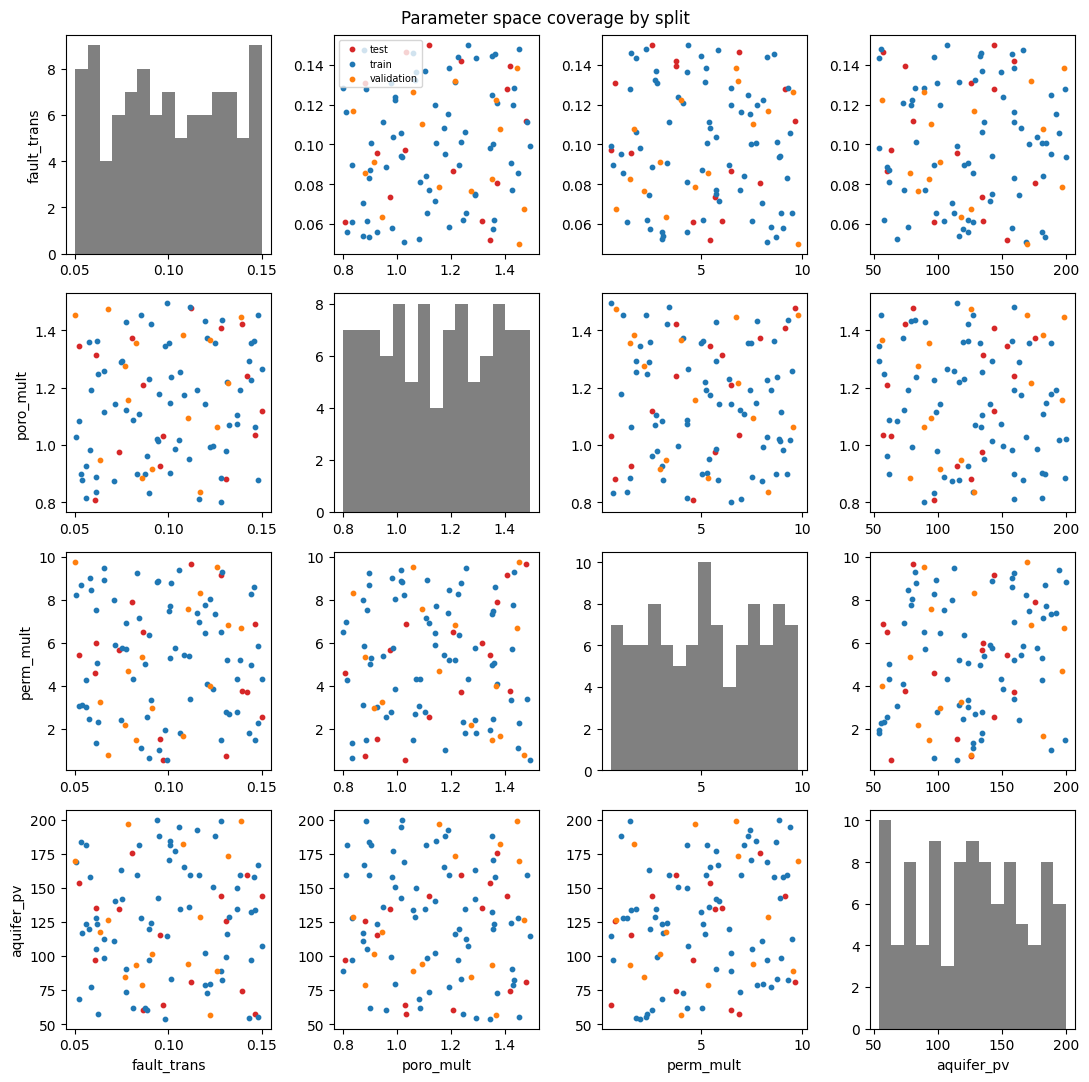

In [4]:
# ---------------------------------------------------------------- 2. parameter space
print("\n== 2. Parameter space ==")
# Count val/test values that fall outside the TRAIN range (models must extrapolate there)
out = []
for p in P:
    lo, hi = bounds.loc[p, "train_min"], bounds.loc[p, "train_max"]
    n_out = int(((cases[p] < lo) | (cases[p] > hi))[~tr].sum())
    out.append((p, n_out))
print("val/test cases outside train range:", out)
print("parameter correlations (should be ~0 if sampling is space-filling):")
print(cases[P].corr().round(2))

# Pairwise scatter (lower/upper) + histogram (diagonal), coloured by split
fig, ax = plt.subplots(4, 4, figsize=(11, 11))
col = {"train": "tab:blue", "validation": "tab:orange", "test": "tab:red"}
for i, a in enumerate(P):
    for j, b in enumerate(P):
        axx = ax[i, j]
        if i == j:
            axx.hist(cases[a], bins=15, color="grey")
        else:
            for s, g in cases.groupby("split"):
                axx.scatter(g[b], g[a], s=10, c=col[s], label=s)
        if i == 3: axx.set_xlabel(b)
        if j == 0: axx.set_ylabel(a)
ax[0, 1].legend(fontsize=7)
plt.suptitle("Parameter space coverage by split")
plt.tight_layout(); plt.savefig(OUT + "01_param_space.png", dpi=110)
plt.show()

## 3. Curves vs observed history
**Result:** the history lies inside the cloud of simulated curves, so a history match is feasible. At the final date the history sits above ~74% of cases for gas and oil but above only ~27% for water – i.e. it looks like a *high-oil/gas, low-water* case, which foreshadows the high `poro_mult` found in section 8.

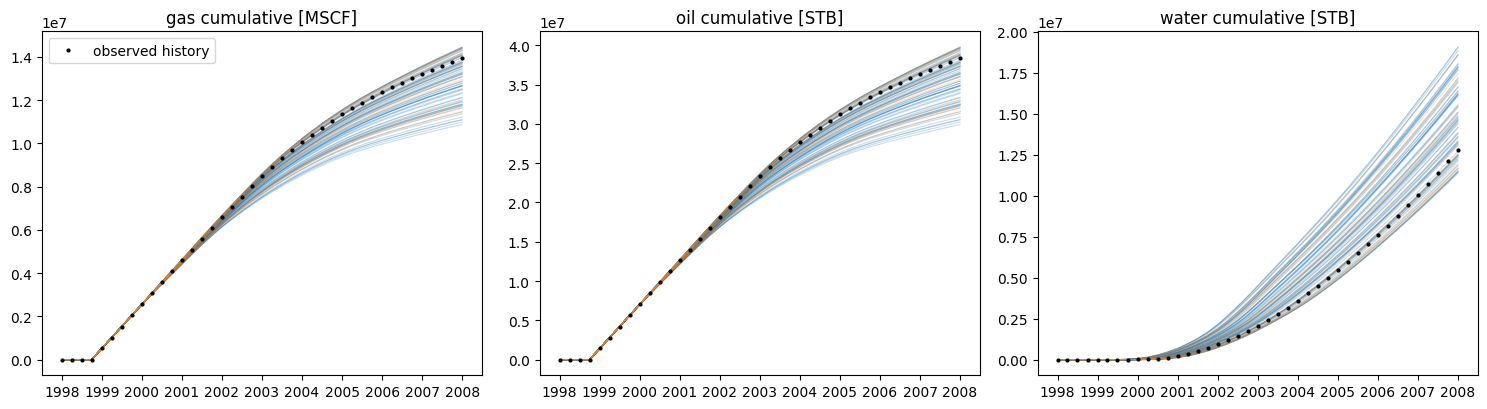

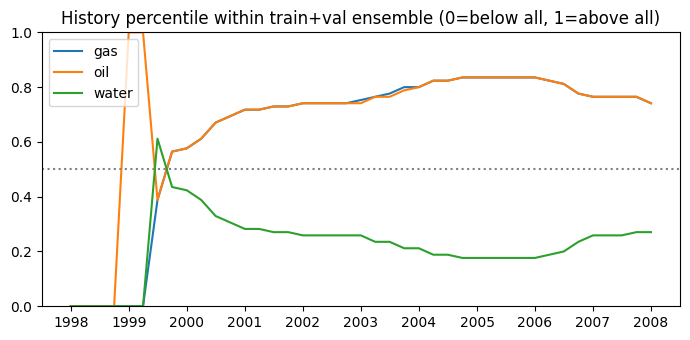


== 3. History percentile at last date (gas, oil, water): [0.74 0.74 0.27]


In [5]:
# ---------------------------------------------------------------- 3. curves vs history
# Spaghetti plot: every train/val case vs the observed history (black dots)
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
for k, q in enumerate(Q):
    for c in np.where(known)[0]:
        ax[k].plot(dates, Y[c, :, k], color="tab:blue" if tr[c] else "tab:orange", alpha=.25, lw=.8)
    ax[k].plot(dates, yh[:, k], "k.", ms=4, label="observed history")
    ax[k].set_title(f"{q} cumulative [{UNIT[q]}]")
ax[0].legend()
plt.tight_layout(); plt.savefig(OUT + "02_curves_vs_history.png", dpi=110)
plt.show()

# where does history sit inside the ensemble over time? (percentile rank)
# Fraction of cases lying BELOW the history at each date (0 = history under all cases, 1 = above all)
rank = np.stack([(Y[known][:, :, k] < yh[None, :, k]).mean(0) for k in range(3)], 1)
fig, ax = plt.subplots(figsize=(7, 3.5))
for k, q in enumerate(Q):
    ax.plot(dates, rank[:, k], label=q)
ax.axhline(.5, c="grey", ls=":"); ax.set_ylim(0, 1)
ax.set_title("History percentile within train+val ensemble (0=below all, 1=above all)")
ax.legend(); plt.tight_layout(); plt.savefig(OUT + "03_history_percentile.png", dpi=110)
plt.show()
print("\n== 3. History percentile at last date (gas, oil, water):", rank[-1].round(2))

## 4. When do cases separate?
**Result:** the oil spread reaches half its final size around **April 2004**, so cases differ gradually over the first ~6 years. Early dates barely discriminate between cases; **late-history points carry most of the information** for matching.

*Caveat:* this is partly a scale effect (cumulative spread grows as cumulative grows).

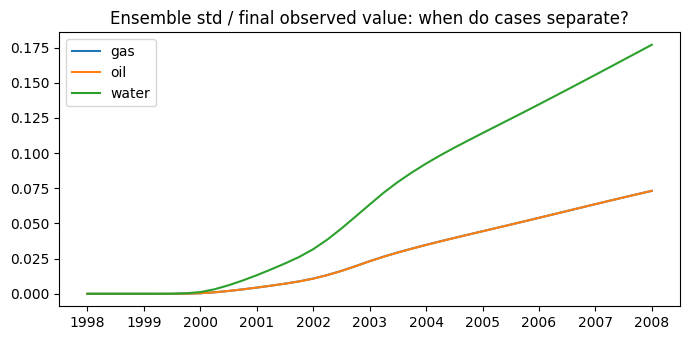

== 4. Oil spread reaches half its final size at 2004-04-01


In [6]:
# ---------------------------------------------------------------- 4. spread over time
# Std across cases, normalised by the history maximum -> comparable across gas/oil/water.
# Note: cumulative spread grows partly just because cumulative grows (scale effect).
spread = np.stack([Y[known][:, :, k].std(0) / (np.abs(yh[:, k]).max() + 1e-9) for k in range(3)], 1)
fig, ax = plt.subplots(figsize=(7, 3.5))
for k, q in enumerate(Q):
    ax.plot(dates, spread[:, k], label=q)
ax.set_title("Ensemble std / final observed value: when do cases separate?")
ax.legend(); plt.tight_layout(); plt.savefig(OUT + "04_spread_over_time.png", dpi=110)
plt.show()
half = int(np.argmax(spread[:, 1] > .5 * spread[-1, 1]))
print("== 4. Oil spread reaches half its final size at", dates[half].date())


## 5. Which parameter drives what?
**Result (raw Spearman, final cumulative):** `poro_mult` dominates (+0.99 for gas and oil, −0.99 for water, established by ~1999 and constant afterwards). `fault_trans` is weak (~±0.15); `perm_mult` and `aquifer_pv` look close to zero.

**Warning in the output:** a `ConstantInputWarning` appears because gas cumulative is identical (0) across cases on the earliest date – harmless.

**Next cell:** raw correlations are misleading here because porosity swamps everything else.


== 5. Spearman rho of each parameter vs FINAL cumulative (train+val) ==
              gas   oil  water
fault_trans  0.15  0.15  -0.15
poro_mult    0.99  0.99  -0.99
perm_mult   -0.03 -0.03   0.12
aquifer_pv  -0.12 -0.12   0.18


c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\nanops.py:1672: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


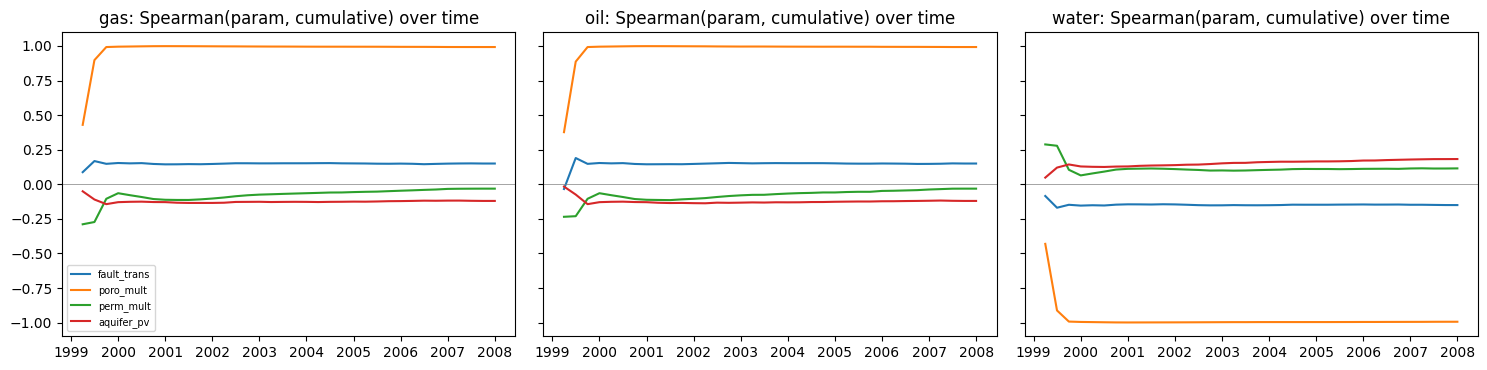

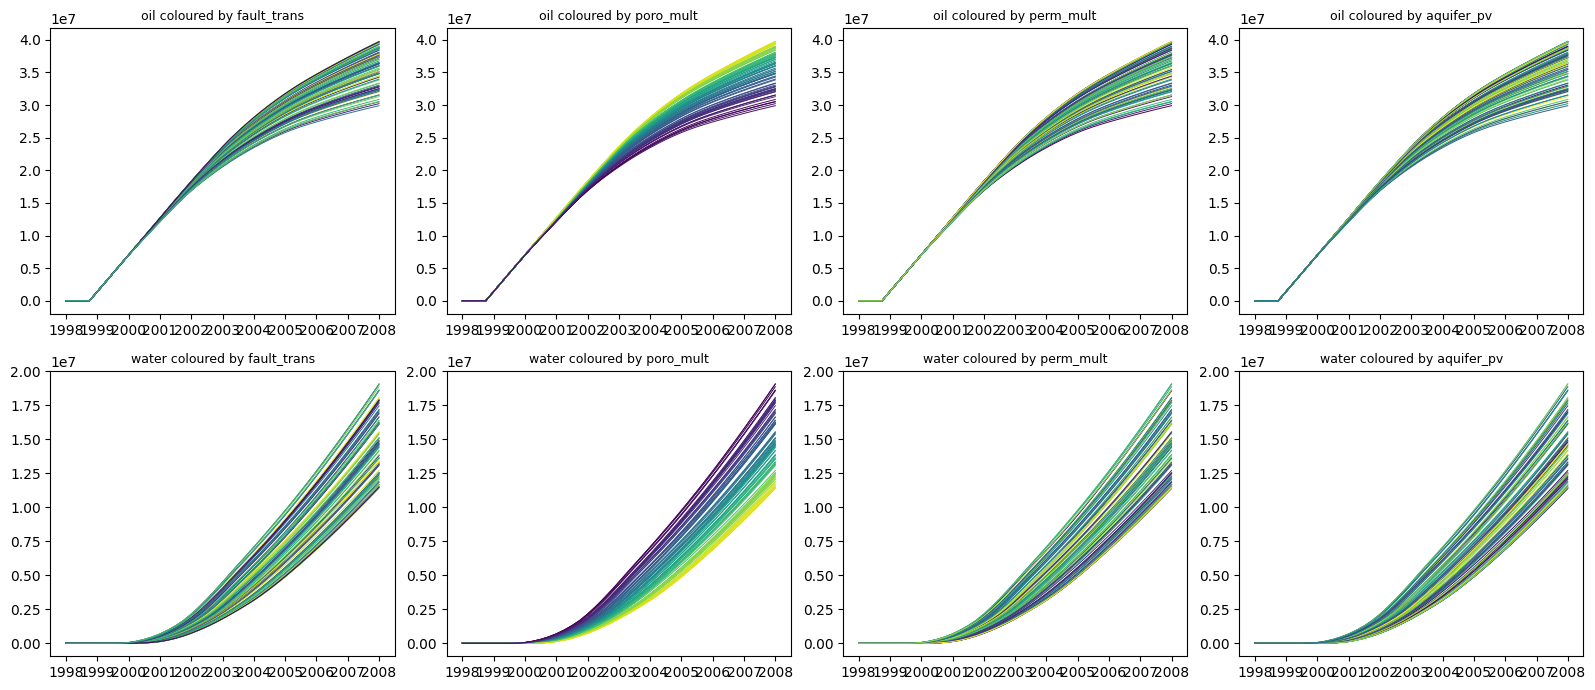

In [7]:
# ---------------------------------------------------------------- 5. parameter -> outcome
print("\n== 5. Spearman rho of each parameter vs FINAL cumulative (train+val) ==")
# Rank (Spearman) correlation: robust to nonlinearity, only needs a monotonic relation
rho = pd.DataFrame({q: [pd.Series(cases.loc[known, p].values).corr(
        pd.Series(Y[known, -1, k]), method="spearman") for p in P]
        for k, q in enumerate(Q)}, index=P).round(2)
print(rho)

# sensitivity over time (which parameter matters when)
# Same correlation at every date (t starts at 1 because gas cumulative is constant 0 at t=0;
# a ConstantInputWarning on the earliest dates is expected and harmless)
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8), sharey=True)
for k, q in enumerate(Q):
    for p in P:
        r = [pd.Series(cases.loc[known, p].values).corr(pd.Series(Y[known, t, k]), method="spearman")
             for t in range(1, len(dates))]
        ax[k].plot(dates[1:], r, label=p)
    ax[k].set_title(f"{q}: Spearman(param, cumulative) over time"); ax[k].axhline(0, c="grey", lw=.5)
ax[0].legend(fontsize=7)
plt.tight_layout(); plt.savefig(OUT + "05_sensitivity_over_time.png", dpi=110)
plt.show()

# curves coloured by each parameter (oil + water)
fig, ax = plt.subplots(2, 4, figsize=(16, 7))
for r, k in enumerate([1, 2]):
    for j, p in enumerate(P):
        v = cases.loc[known, p].values
        for n, c in enumerate(np.where(known)[0]):
            ax[r, j].plot(dates, Y[c, :, k], c=plt.cm.viridis((v[n] - v.min()) / (np.ptp(v) + 1e-9)), lw=.7)
        ax[r, j].set_title(f"{Q[k]} coloured by {p}", fontsize=9)
plt.tight_layout(); plt.savefig(OUT + "06_curves_by_param.png", dpi=110)
plt.show()

### 5b. Residual analysis after removing the porosity trend
A quadratic in `poro_mult` alone explains ~98.6% of the variance in final oil/gas and ~99.3% in water. In the **residual**, `perm_mult` correlates strongly with oil and gas (ρ ≈ 0.89) and `aquifer_pv` with water (ρ ≈ 0.83); `fault_trans` stays ≈ 0. So the picture is: **porosity sets the level, permeability refines oil/gas, the aquifer refines water.** Keep all four inputs in the proxy.

In [ ]:
# Remove the dominant poro_mult trend (quadratic fit to FINAL cumulative), then check what the
# other parameters explain in the RESIDUAL. Raw correlations hide perm_mult / aquifer_pv.
x = cases.loc[known, "poro_mult"].values
for k, q in enumerate(Q):
    y = Y[known, -1, k]
    resid = y - np.polyval(np.polyfit(x, y, 2), x)
    others = {p: round(float(pd.Series(cases.loc[known, p].values).corr(pd.Series(resid), method="spearman")), 2)
              for p in P if p != "poro_mult"}
    print(f"{q:5s} R2(poro_mult only) = {1 - resid.var() / y.var():.4f} | residual Spearman vs others: {others}")

gas   R2(poro_mult only) = 0.9859 | residual Spearman vs others: {'fault_trans': -0.03, 'perm_mult': 0.89, 'aquifer_pv': 0.02}
oil   R2(poro_mult only) = 0.9860 | residual Spearman vs others: {'fault_trans': -0.03, 'perm_mult': 0.89, 'aquifer_pv': 0.01}
water R2(poro_mult only) = 0.9925 | residual Spearman vs others: {'fault_trans': -0.04, 'perm_mult': -0.1, 'aquifer_pv': 0.83}


## 6. Dimensionality of the curves (PCA)
**Result:** one component explains >99.9% of the variance for each quantity (>99.98% with two). The curves are essentially one-dimensional, which supports a proxy that predicts a few PCA coefficients instead of 41 time points.

*Caveat:* that variance is dominated by the shared porosity scale. Choose the number of components (3-5 is safe) by **reconstruction error on validation**, not by variance explained.

In [8]:
# ---------------------------------------------------------------- 6. dimensionality (PCA)
print("\n== 6. PCA of curves (train only): variance explained by 1/2/3/5 components ==")
# SVD of the mean-centred train curves; squared singular values = variance per component
for k, q in enumerate(Q):
    X = Y[tr][:, :, k]; Xc = X - X.mean(0)
    s = np.linalg.svd(Xc, compute_uv=False) ** 2
    ev = np.cumsum(s) / s.sum()
    print(q, [round(float(ev[i]), 4) for i in (0, 1, 2, 4)])


== 6. PCA of curves (train only): variance explained by 1/2/3/5 components ==
gas [0.9996, 0.9999, 1.0, 1.0]
oil [0.9995, 0.9999, 1.0, 1.0]
water [0.9991, 0.9998, 1.0, 1.0]


## 7. Rates and forecast hints
**Result (last four quarters of history):** gas rate 2114 → 1906 and oil rate 5819 → 5247 (falling ~10%), water rate 7257 → 7782 (rising ~7%), water injection almost flat at ~9.3k. Water cut climbs from 0 → 0.22 (mid-history) → **0.60 at the end**.

**Implication:** the history ends in the middle of a decline/water-breakthrough phase. The simulated cases stop at 2008-01-01, so the 20-year forecast must **extrapolate** this trend; plan a time-extrapolation backtest, not just interpolation accuracy.


== 7. Late-history rate trend (avg rate, last 4 quarters, history) ==
      date  gas_rate_avg  oil_rate_avg  water_rate_avg  water_inj_rate
2007-04-01      2113.996   5818.849146     7257.183183         9365.98
2007-07-01      2043.347   5624.407142     7440.391187         9348.63
2007-10-01      1973.905   5433.262137     7615.672192         9336.73
2008-01-01      1905.583   5246.799132     7782.265196         9326.61


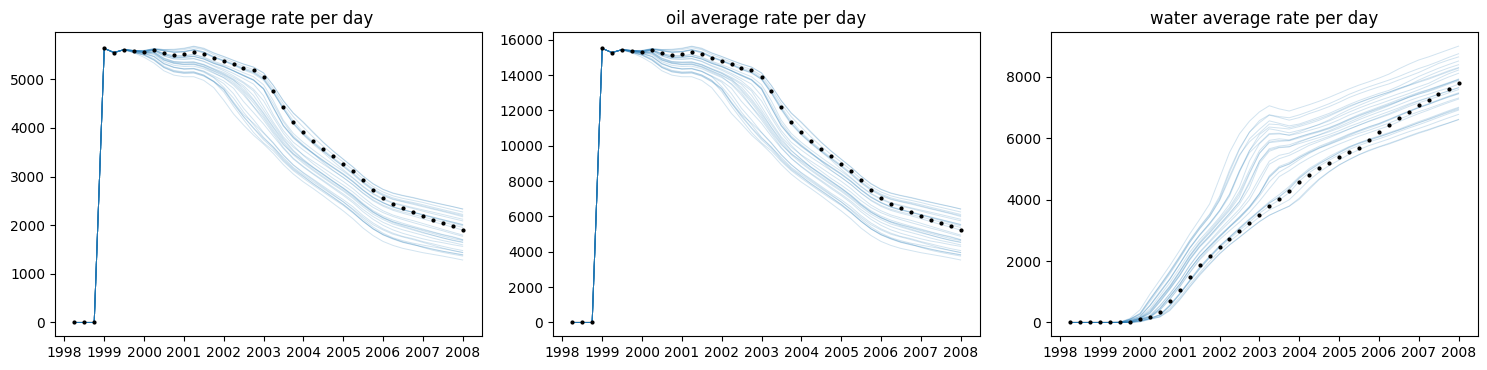

history water cut, first/mid/last quarter: [0.    0.223 0.597]


In [9]:
# ---------------------------------------------------------------- 7. rates & forecast hints
print("\n== 7. Late-history rate trend (avg rate, last 4 quarters, history) ==")
print(hist[["date", "gas_rate_avg", "oil_rate_avg", "water_rate_avg", "water_inj_rate"]].tail(4).to_string(index=False))
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
for k, q in enumerate(Q):
    for c in np.where(known)[0][::3]:
        g = cq[cq.case_id == c + 1]
        ax[k].plot(g.date, g[f"{q}_rate_avg"], color="tab:blue", alpha=.2, lw=.7)
    ax[k].plot(hist.date, hist[f"{q}_rate_avg"], "k.", ms=4)
    ax[k].set_title(f"{q} average rate per day")
plt.tight_layout(); plt.savefig(OUT + "07_rates.png", dpi=110)
plt.show()

# water cut and GOR from history vs ensemble (derived quantities often reveal regime changes)
# Water cut = water / (water + oil) produced per quarter (from cumulative increments)
wc = np.diff(yh[:, 2]) / (np.diff(yh[:, 2]) + np.diff(yh[:, 1]) + 1e-9)
print("history water cut, first/mid/last quarter:", wc[[1, 20, -1]].round(3))

## 8. Which cases match the history, and which parameters are identifiable?
**Result:** the 10 best train/val cases all have `poro_mult` ≈ 1.35-1.38, while `fault_trans`, `perm_mult` and `aquifer_pv` span wide ranges. Spread of the top-10 relative to the full range: `poro_mult` **0.02** vs **0.28-0.32** for the others.

**Implication:** the history pins down porosity but not the other three parameters – many different parameter sets match equally well. When choosing the 10 forecast cases, favour **diversity** within the well-matching set so the forecast reflects the remaining uncertainty. The raw-misfit ranking here is only a screening step, not the final matching objective.


== 8. 10 best train/val cases by raw misfit ==
  case_id      split  fault_trans  poro_mult  perm_mult  aquifer_pv  misfit
      11      train     0.125000   1.353783   7.337727  188.082217  0.0023
      76 validation     0.107853   1.383307   1.640472  182.202216  0.0023
      40      train     0.144337   1.354258   4.961321  132.522202  0.0023
       6      train     0.057691   1.358438   2.468451  119.765313  0.0023
      50      train     0.100253   1.356740   7.458742  170.738853  0.0024
      20      train     0.061818   1.361147   5.078480  123.382672  0.0026
      73 validation     0.082556   1.353836   1.474943   93.315226  0.0027
      26      train     0.098038   1.346407   1.943019   53.952910  0.0032
       4      train     0.145503   1.364136   8.602499  158.106937  0.0037
      51      train     0.120661   1.371251   4.074631   72.756127  0.0059


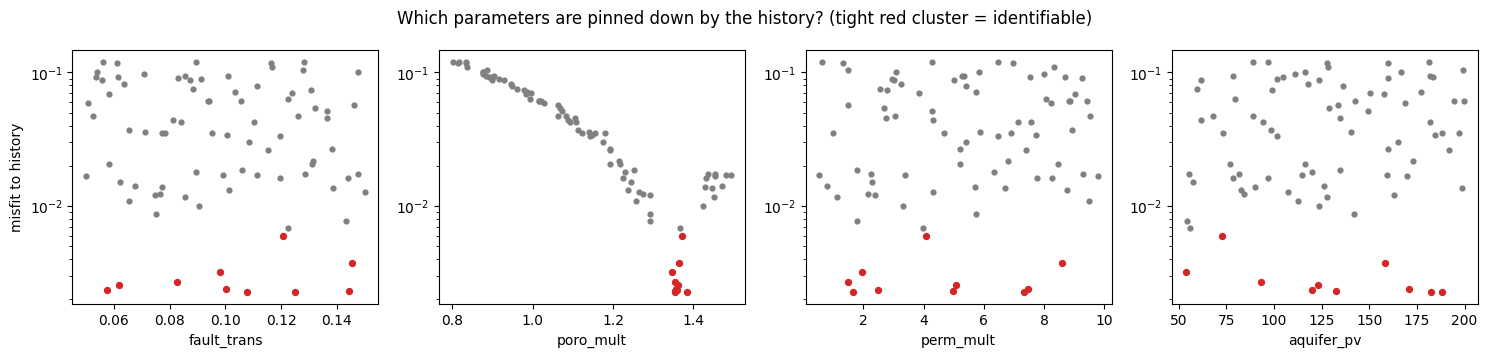

top-10 std / full range (small = well constrained):
{'fault_trans': 0.31, 'poro_mult': 0.02, 'perm_mult': 0.28, 'aquifer_pv': 0.32}

Figures written to eda_figs/


In [10]:
# ---------------------------------------------------------------- 8. who matches history?
# Crude screening misfit: mean |case - history| / history max over all dates and quantities.
# Not the final matching objective - just to see which parameters the history favours.
sc = np.maximum(yh.max(0), 1)                    # scale each quantity by its history maximum
mis = np.abs((Y - yh[None]) / sc).mean(axis=(1, 2))
order = [c for c in np.argsort(mis) if known[c]][:10]
top = cases.iloc[order][["case_id", "split"] + P].assign(misfit=mis[order].round(4))
print("\n== 8. 10 best train/val cases by raw misfit ==\n", top.to_string(index=False))

fig, ax = plt.subplots(1, 4, figsize=(15, 3.6))
for j, p in enumerate(P):
    ax[j].scatter(cases.loc[known, p], mis[known], s=12, c="grey")
    ax[j].scatter(cases.iloc[order][p], mis[order], s=18, c="tab:red")
    ax[j].set_xlabel(p); ax[j].set_yscale("log")
ax[0].set_ylabel("misfit to history")
plt.suptitle("Which parameters are pinned down by the history? (tight red cluster = identifiable)")
plt.tight_layout(); plt.savefig(OUT + "08_identifiability.png", dpi=110)
plt.show()
print("top-10 std / full range (small = well constrained):")
print({p: round(float(cases.iloc[order][p].std() / np.ptp(cases[p])), 2) for p in P})
print("\nFigures written to", OUT)